# Recruiting Funnel Drop-off & Diversity Analysis
Here’s a hiring funnel dataset — applications, interviews, offers, hires — split by gender and region. Analyze the funnel and identify bias or inefficiency."
What You’ll Likely Do:
* Funnel conversion rates by stage (groupby(['gender', 'stage']))
* Compare success rates by demographic
* Time-to-hire and conversion by department or recruiter
* Identify gaps (e.g., diversity bottlenecks)
What to Prepare:
* Funnel analysis logic
* groupby().size().unstack(), crosstab, bar plots
Insights like: “Offer acceptance rate for women is 25% lower in Tech roles — potentially investigate comp gaps.” create a dataset where i can practice for my 2 hours interview

# Data Rediness

In [5]:
#import all libraries

import pandas as pd
import numpy as np
from datetime import datetime
from dateutil import parser
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [9]:
# Load data

df=pd.read_csv('recruiting_funnel_data_messy.csv')
df.head()

,application_id,stage,outcome,gender,department,region,experience_level,years_experience,university,gpa,...,application_date,stage_date,days_in_stage,days_since_application,interviewer_rating,interview_notes,salary_offered,salary_accepted,quarter,month
0,APP_00001,Application,Advanced,Male,Product,North America,Entry,1.049549,UCLA,NaN,...,2025-01-30 04:04:49.887103,2025-01-30 04:04:49.887103,0,0.0,NaN,NaN,NaN,NaN,2025Q1,2025-01
1,APP_00002,Application,Advanced,Female,Operations,Latin America,Staff/Principal,11.256188,State University.,3.353741,...,2025-06-15 04:04:49.887811,2025-06-15 04:04:49.887811,0,0.0,NaN,NaN,NaN,NaN,2025Q2,2025-06
2,APP_00003,Application,Advanced,Male,Product,Europe,Senior,8.559995,State University,3.434819,...,2025-03-18 04:04:49.887992,2025-03-18 04:04:49.887992,0,0.0,NaN,NaN,NaN,NaN,2025Q1,2025-03
3,APP_00004,Application,Advanced,Male,Operations,Asia Pacific,Entry,0.073774,UCLA,2.632492,...,2025-03-08 04:04:49.888144,2025-03-08 04:04:49.888144,0,0.0,NaN,NaN,NaN,NaN,2025Q1,2025-03
4,APP_00005,Application,Advanced,Male,Engineering,Asia Pacific,Entry,1.059301,Columbia,3.817544,...,2025-01-29 04:04:49.888305,2025-01-29 04:04:49.888305,0,0.0,NaN,NaN,NaN,NaN,2025Q1,2025-01


In [11]:
df.shape

(15011, 28)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15011 entries, 0 to 15010
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   application_id          15011 non-null  object 
 1   stage                   15011 non-null  object 
 2   outcome                 15011 non-null  object 
 3   gender                  14670 non-null  object 
 4   department              15011 non-null  object 
 5   region                  15011 non-null  object 
 6   experience_level        14713 non-null  object 
 7   years_experience        14299 non-null  float64
 8   university              15011 non-null  object 
 9   gpa                     14066 non-null  float64
 10  recruiter               15011 non-null  object 
 11  source                  15011 non-null  object 
 12  skills                  15011 non-null  object 
 13  num_skills              15011 non-null  int64  
 14  resume_score            12072 non-null

In [15]:
df.describe(include='all')

,application_id,stage,outcome,gender,department,region,experience_level,years_experience,university,gpa,...,application_date,stage_date,days_in_stage,days_since_application,interviewer_rating,interview_notes,salary_offered,salary_accepted,quarter,month
count,15011,15011,15011,14670,15011,15011,14713,14299.000000,15011,14066.000000,...,14670,14670,15011.000000,14670.000000,6118.000000,3480,1.077000e+03,4.840000e+02,14670,14670
unique,5000,7,2,7,39,22,7,NaN,89,NaN,...,4886,14523,NaN,NaN,NaN,28,NaN,NaN,2,6
top,APP_02055,Application,Advanced,Male,HR,Europe,Mid,NaN,Georgia Tech,NaN,...,2025-06-28 04:04:50.172833,2025-04-03 04:04:50.337876,NaN,NaN,NaN,Concerns about technical depth,NaN,NaN,2025Q1,2025-03
freq,9,5052,10471,9518,1901,3795,5667,NaN,860,NaN,...,9,2,NaN,NaN,NaN,441,NaN,NaN,7388,2644
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.048494,NaN,6.773102,...,NaN,NaN,7.243022,16.043899,2.951455,NaN,1.190120e+05,1.159340e+05,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54.562298,NaN,27.302575,...,NaN,NaN,16.792501,30.493154,1.363396,NaN,1.677955e+05,1.490613e+05,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002059,NaN,2.015981,...,NaN,NaN,0.000000,0.000000,1.000000,NaN,5.570000e+03,3.680000e+04,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.876610,NaN,3.137905,...,NaN,NaN,0.000000,0.000000,2.000000,NaN,6.958800e+04,6.947700e+04,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.732339,NaN,3.428832,...,NaN,NaN,5.000000,5.000000,3.000000,NaN,9.108900e+04,9.422900e+04,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.474847,NaN,3.711864,...,NaN,NaN,8.000000,17.000000,4.000000,NaN,1.228210e+05,1.250588e+05,NaN,NaN


## Data Cleaning

In [18]:
#data cleaning for all categoricals

categoricals_cols=df.select_dtypes(include=['object']).columns
for col in categoricals_cols:
    print(f"\n {col} - Unique Values: ")
    print(df[col].unique())


 application_id - Unique Values: 
['APP_00001' 'APP_00002' 'APP_00003' ... 'APP_04998' 'APP_04999'
 'APP_05000']

 stage - Unique Values: 
['Application' 'Phone Screen' 'Technical Interview' 'Panel Interview'
 'Final Interview' 'Offer' 'Hire']

 outcome - Unique Values: 
['Advanced' 'Rejected']

 gender - Unique Values: 
['Male' 'Female' nan 'Non-binary' 'MALE' 'Prefer not to say' 'FEMALE'
 'NON-BINARY']

 department - Unique Values: 
['Product' 'Operations' 'Engineering' 'HR' 'Finance' 'Marketing'
 'Data Science' 'Sales' 'Op3rations' 'Financ3' 'Sales.' 'engineering'
 'finance' 'Data_Science' 'Sal3s' ' Engineering ' 'HR.' 'Finance.'
 'Data Sci3nc3' 'Engin33ring' 'hr' 'Marketing.' ' Sales ' 'Product.'
 ' Finance ' ' HR ' 'Operations.' 'product' ' Product ' 'marketing'
 'operations' 'data science' ' Marketing ' 'Mark3ting' 'Engineering.'
 'sales' ' Operations ' ' Data Science ' 'Data Science.']

 region - Unique Values: 
['North America' 'Latin America' 'Europe' 'Asia Pacific' 'Europ3'


In [26]:
#Handling cat
cols_to_clean=df.select_dtypes(include=['object']).columns
df[cols_to_clean]=df[cols_to_clean].apply(lambda col:col.str.strip().str.title())

In [30]:
df['gender'].unique()

array(['Male', 'Female', nan, 'Non-Binary', 'Prefer Not To Say'],
      dtype=object)

In [48]:
#cleaning Gender
mapping={'Prefer Not To Say':'Non-Binary','Non-binary':'Non-Binary'}
df['gender']=df['gender'].replace(mapping)

In [50]:
df['gender'].unique()

array(['Male', 'Female', nan, 'Non-Binary'], dtype=object)

In [57]:
mapping={'Op3Rations':'Operations','Financ3':'Finance','Sales.':'Sales','Data_Science':'Data Science',
        'Sal3S':'Sales','Hr.':'HR','Finance.':'Finance','Data Sci3Nc3':'Data Science','Engin33Ring':'Engineering',
        'Marketing.':'Marketing', 
         'Product.':'Product',
       'Operations.':'Operations', 
         'Mark3Ting':'Marketing', 
         'Engineering.':'Engineering', 
         'Data Science.':'Data Science'}
df['department']=df['department'].replace(mapping)

In [59]:
df['department'].unique()

array(['Product', 'Operations', 'Engineering', 'Hr', 'Finance',
       'Marketing', 'Data Science', 'Sales', 'HR'], dtype=object)

In [71]:
import re

def clean_text_column(series):
    return (
        series.astype(str)
        .str.lower()
        .str.replace(r'[^\w\s]', '', regex=True)
        .str.replace('_', ' ', regex=False)
        .str.replace('3', 'e', regex=False)
        .str.strip()
        .str.title()
    )

# Clean each column accordingly
columns_to_clean = [
    'gender',
    'department',
    'region',
    'experience_level',
    'university',
    'source',
    'previous_company_type'
]

for col in columns_to_clean:
    df[col] = clean_text_column(df[col])

# Clean 'skills' separately (ensure unique skills and order maintained)
df['skills'] = (
    df['skills']
    .astype(str)
    .str.lower()
    .str.replace(r'[^\w,\s]', '', regex=True)
    .str.replace('3', 'e')
    .apply(lambda x: ', '.join(sorted(set([skill.strip().title() for skill in x.split(',')]))))
)

# Optional: Replace exact known terms post-cleaning (mapping)
df['gender'] = df['gender'].replace({
    'Prefer Not To Say': 'Prefer Not to Say',
    'Nonbinary': 'Non-binary'
})

df['experience_level'] = df['experience_level'].replace({
    'Staffprincipal': 'Staff/Principal'
})

df['previous_company_type'] = df['previous_company_type'].replace({
    'Big Tech': 'Big Tech',
    'Nonprofit': 'Non-profit'
})

# Final check of cleaned values
for col in ['gender', 'department', 'region', 'experience_level', 'university', 'source', 'skills', 'previous_company_type']:
    print(f"{col} - Unique Cleaned Values:\n", df[col].unique(), "\n")


gender - Unique Cleaned Values:
 ['Male' 'Female' 'Nan' 'Non-binary'] 

department - Unique Cleaned Values:
 ['Product' 'Operations' 'Engineering' 'Hr' 'Finance' 'Marketing'
 'Data Science' 'Sales'] 

region - Unique Cleaned Values:
 ['North America' 'Latin America' 'Europe' 'Asia Pacific'] 

experience_level - Unique Cleaned Values:
 ['Entry' 'Staff/Principal' 'Senior' 'Mid' 'Nan'] 

university - Unique Cleaned Values:
 ['Ucla' 'State University' 'Columbia' 'University Of Washington'
 'Uc Berkeley' 'Mit' 'International University' 'Cmu' 'Yale' 'Harvard'
 'Stanford' 'Usc' 'Princeton' 'Nyu' 'Online University' 'Ut Austin'
 'Community College' 'Georgia Tech'] 

source - Unique Cleaned Values:
 ['Job Fair' 'Referral' 'Recruiter Outreach' 'Company Website' 'Linkedin'
 'University Career Fair' 'Indeed'] 

skills - Unique Cleaned Values:
 ['Analytics, Aws, Sql, Tableau'
 'Aws, Javascript, Machine Learning, Project Management, React, Sql'
 'Communication, Excel, Project Management, Python, Re

In [73]:
df.columns

Index(['application_id', 'stage', 'outcome', 'gender', 'department', 'region',
       'experience_level', 'years_experience', 'university', 'gpa',
       'recruiter', 'source', 'skills', 'num_skills', 'resume_score',
       'previous_company_type', 'phone', 'email', 'application_date',
       'stage_date', 'days_in_stage', 'days_since_application',
       'interviewer_rating', 'interview_notes', 'salary_offered',
       'salary_accepted', 'quarter', 'month'],
      dtype='object')

In [75]:
df.head()


,application_id,stage,outcome,gender,department,region,experience_level,years_experience,university,gpa,...,application_date,stage_date,days_in_stage,days_since_application,interviewer_rating,interview_notes,salary_offered,salary_accepted,quarter,month
0,App_00001,Application,Advanced,Male,Product,North America,Entry,1.049549,Ucla,NaN,...,2025-01-30 04:04:49.887103,2025-01-30 04:04:49.887103,0,0.0,NaN,NaN,NaN,NaN,2025Q1,2025-01
1,App_00002,Application,Advanced,Female,Operations,Latin America,Staff/Principal,11.256188,State University,3.353741,...,2025-06-15 04:04:49.887811,2025-06-15 04:04:49.887811,0,0.0,NaN,NaN,NaN,NaN,2025Q2,2025-06
2,App_00003,Application,Advanced,Male,Product,Europe,Senior,8.559995,State University,3.434819,...,2025-03-18 04:04:49.887992,2025-03-18 04:04:49.887992,0,0.0,NaN,NaN,NaN,NaN,2025Q1,2025-03
3,App_00004,Application,Advanced,Male,Operations,Asia Pacific,Entry,0.073774,Ucla,2.632492,...,2025-03-08 04:04:49.888144,2025-03-08 04:04:49.888144,0,0.0,NaN,NaN,NaN,NaN,2025Q1,2025-03
4,App_00005,Application,Advanced,Male,Engineering,Asia Pacific,Entry,1.059301,Columbia,3.817544,...,2025-01-29 04:04:49.888305,2025-01-29 04:04:49.888305,0,0.0,NaN,NaN,NaN,NaN,2025Q1,2025-01


In [79]:
df.isna().sum()

application_id                0
stage                         0
outcome                       0
gender                        0
department                    0
region                        0
experience_level              0
years_experience            712
university                    0
gpa                         945
recruiter                     0
source                        0
skills                        0
num_skills                    0
resume_score               2939
previous_company_type         0
phone                       717
email                       269
application_date            341
stage_date                  341
days_in_stage                 0
days_since_application      341
interviewer_rating         8893
interview_notes           11531
salary_offered            13934
salary_accepted           14527
quarter                     341
month                       341
dtype: int64

In [81]:
df.duplicated().sum()

148

In [83]:
df=df.drop_duplicates(keep='first')

In [85]:
df.duplicated().sum()

0

In [91]:
df.head()


,application_id,stage,outcome,gender,department,region,experience_level,years_experience,university,gpa,...,application_date,stage_date,days_in_stage,days_since_application,interviewer_rating,interview_notes,salary_offered,salary_accepted,quarter,month
0,App_00001,Application,Advanced,Male,Product,North America,Entry,1.049549,Ucla,NaN,...,2025-01-30 04:04:49.887103,2025-01-30 04:04:49.887103,0,0.0,NaN,NaN,NaN,NaN,2025Q1,2025-01
1,App_00002,Application,Advanced,Female,Operations,Latin America,Staff/Principal,11.256188,State University,3.353741,...,2025-06-15 04:04:49.887811,2025-06-15 04:04:49.887811,0,0.0,NaN,NaN,NaN,NaN,2025Q2,2025-06
2,App_00003,Application,Advanced,Male,Product,Europe,Senior,8.559995,State University,3.434819,...,2025-03-18 04:04:49.887992,2025-03-18 04:04:49.887992,0,0.0,NaN,NaN,NaN,NaN,2025Q1,2025-03
3,App_00004,Application,Advanced,Male,Operations,Asia Pacific,Entry,0.073774,Ucla,2.632492,...,2025-03-08 04:04:49.888144,2025-03-08 04:04:49.888144,0,0.0,NaN,NaN,NaN,NaN,2025Q1,2025-03
4,App_00005,Application,Advanced,Male,Engineering,Asia Pacific,Entry,1.059301,Columbia,3.817544,...,2025-01-29 04:04:49.888305,2025-01-29 04:04:49.888305,0,0.0,NaN,NaN,NaN,NaN,2025Q1,2025-01


In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14863 entries, 0 to 14862
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   application_id          14863 non-null  object 
 1   stage                   14863 non-null  object 
 2   outcome                 14863 non-null  object 
 3   gender                  14863 non-null  object 
 4   department              14863 non-null  object 
 5   region                  14863 non-null  object 
 6   experience_level        14863 non-null  object 
 7   years_experience        14156 non-null  float64
 8   university              14863 non-null  object 
 9   gpa                     13935 non-null  float64
 10  recruiter               14863 non-null  object 
 11  source                  14863 non-null  object 
 12  skills                  14863 non-null  object 
 13  num_skills              14863 non-null  int64  
 14  resume_score            11949 non-null  flo

In [103]:
df['stage_date'].unique()

array(['2025-01-30 04:04:49.887103', '2025-06-15 04:04:49.887811',
       '2025-03-18 04:04:49.887992', ..., '2025-04-09 04:04:50.584620',
       '2025-08-11 04:04:50.588325', '2025-05-15 04:04:50.588457'],
      dtype=object)

In [105]:
#convert into date
df['application_date']=pd.to_datetime(df['application_date'],yearfirst=True,errors='coerce')
df['stage_date']=pd.to_datetime(df['stage_date'],yearfirst=True,errors='coerce')

/var/folders/3f/21w5vqzs3k35ybl9kpx55zk40000gn/T/ipykernel_90923/696132516.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['application_date']=pd.to_datetime(df['application_date'],yearfirst=True,errors='coerce')
/var/folders/3f/21w5vqzs3k35ybl9kpx55zk40000gn/T/ipykernel_90923/696132516.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['stage_date']=pd.to_datetime(df['stage_date'],yearfirst=True,errors='coerce')


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14863 entries, 0 to 14862
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   application_id          14863 non-null  object        
 1   stage                   14863 non-null  object        
 2   outcome                 14863 non-null  object        
 3   gender                  14863 non-null  object        
 4   department              14863 non-null  object        
 5   region                  14863 non-null  object        
 6   experience_level        14863 non-null  object        
 7   years_experience        14156 non-null  float64       
 8   university              14863 non-null  object        
 9   gpa                     13935 non-null  float64       
 10  recruiter               14863 non-null  object        
 11  source                  14863 non-null  object        
 12  skills                  14863 non-null  object     

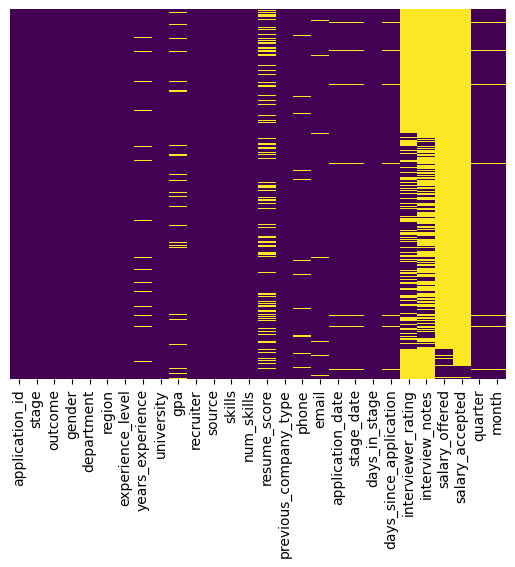

In [89]:
#handling missing values

sns.heatmap(df.isna(),cbar=False,yticklabels=False,cmap='viridis')
plt.show()

In [109]:
#filling missing values
#for numerical values
num_cols=df.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    df[col].fillna(df[col].median(),inplace=True)

#for categorical values
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0],inplace=True)

/var/folders/3f/21w5vqzs3k35ybl9kpx55zk40000gn/T/ipykernel_90923/2945009257.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(),inplace=True)
/var/folders/3f/21w5vqzs3k35ybl9kpx55zk40000gn/T/ipykernel_90923/2945009257.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col].fillna(df[col].median(),inplace=Tru

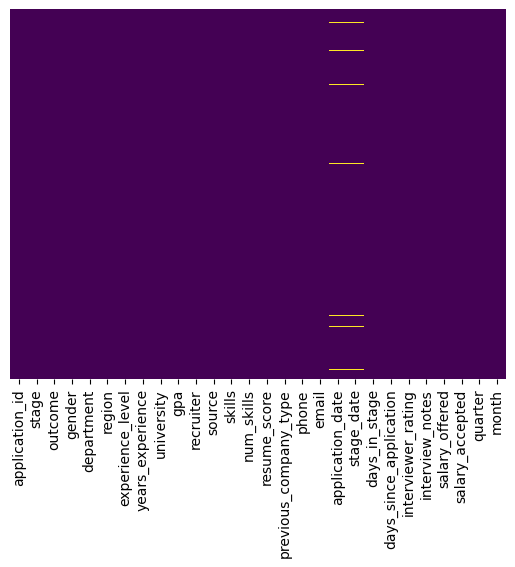

In [111]:
#handling missing values

sns.heatmap(df.isna(),cbar=False,yticklabels=False,cmap='viridis')
plt.show()

In [114]:
df.head()

,application_id,stage,outcome,gender,department,region,experience_level,years_experience,university,gpa,...,application_date,stage_date,days_in_stage,days_since_application,interviewer_rating,interview_notes,salary_offered,salary_accepted,quarter,month
0,App_00001,Application,Advanced,Male,Product,North America,Entry,1.049549,Ucla,3.428883,...,2025-01-30 04:04:49.887103,2025-01-30 04:04:49.887103,0,0.0,3.0,"Excellent Cultural Fit, Very Enthusiastic",90906.0,94229.0,2025Q1,2025-01
1,App_00002,Application,Advanced,Female,Operations,Latin America,Staff/Principal,11.256188,State University,3.353741,...,2025-06-15 04:04:49.887811,2025-06-15 04:04:49.887811,0,0.0,3.0,"Excellent Cultural Fit, Very Enthusiastic",90906.0,94229.0,2025Q2,2025-06
2,App_00003,Application,Advanced,Male,Product,Europe,Senior,8.559995,State University,3.434819,...,2025-03-18 04:04:49.887992,2025-03-18 04:04:49.887992,0,0.0,3.0,"Excellent Cultural Fit, Very Enthusiastic",90906.0,94229.0,2025Q1,2025-03
3,App_00004,Application,Advanced,Male,Operations,Asia Pacific,Entry,0.073774,Ucla,2.632492,...,2025-03-08 04:04:49.888144,2025-03-08 04:04:49.888144,0,0.0,3.0,"Excellent Cultural Fit, Very Enthusiastic",90906.0,94229.0,2025Q1,2025-03
4,App_00005,Application,Advanced,Male,Engineering,Asia Pacific,Entry,1.059301,Columbia,3.817544,...,2025-01-29 04:04:49.888305,2025-01-29 04:04:49.888305,0,0.0,3.0,"Excellent Cultural Fit, Very Enthusiastic",90906.0,94229.0,2025Q1,2025-01


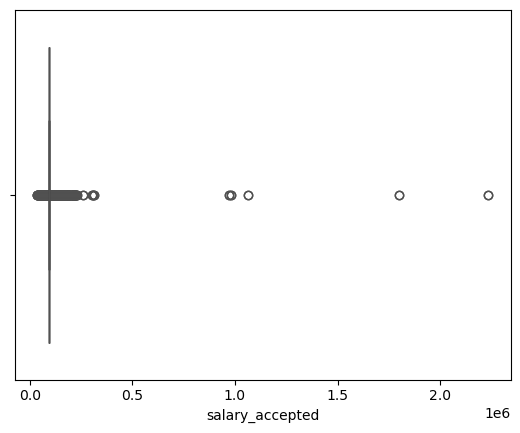

In [118]:
sns.boxplot(x=df['salary_accepted'])
plt.show()

In [122]:
df['is_outlier'] = ((df['salary_accepted'] < lower_bound) | (df['salary_accepted'] > upper_bound)).astype(int)

NameError: name 'lower_bound' is not defined

In [120]:
df.describe()

,years_experience,gpa,num_skills,resume_score,application_date,stage_date,days_in_stage,days_since_application,interviewer_rating,salary_offered,salary_accepted
count,14863.000000,14863.000000,14863.000000,14863.000000,14523,14523,14863.000000,14863.000000,14863.000000,1.486300e+04,1.486300e+04
mean,9.833268,6.536477,4.501783,75.992284,2025-03-31 08:21:08.879151104,2025-04-16 09:24:00.661840896,7.239992,15.791025,2.980690,9.291344e+04,9.493022e+04
min,0.002059,2.015981,2.000000,21.546100,2025-01-01 04:04:49.948489,2025-01-01 04:04:49.948489,0.000000,0.000000,1.000000,5.570000e+03,3.680000e+04
25%,1.988137,3.157668,3.000000,69.016055,2025-02-14 04:04:50.547843072,2025-02-27 04:04:50.277505024,0.000000,0.000000,3.000000,9.090600e+04,9.422900e+04
50%,4.728951,3.428883,4.000000,76.090903,2025-03-31 04:04:50.188282112,2025-04-14 04:04:50.169999872,5.000000,5.000000,3.000000,9.090600e+04,9.422900e+04
75%,8.143264,3.690299,6.000000,83.831280,2025-05-16 04:04:49.945849088,2025-05-31 04:04:50.105874176,8.000000,17.000000,3.000000,9.090600e+04,9.422900e+04
max,1720.636323,388.527711,7.000000,100.000000,2025-06-28 04:04:50.581711,2026-04-29 04:04:49.979419,199.000000,330.000000,5.000000,2.245850e+06,2.235108e+06
std,53.520396,26.333992,1.709759,12.811233,NaN,NaN,16.792164,30.247578,0.870402,4.570347e+04,2.713566e+04


In [124]:
df.nunique()


application_id             5000
stage                         7
outcome                       2
gender                        4
department                    8
region                        4
experience_level              5
years_experience           4778
university                   18
gpa                        4386
recruiter                    20
source                        7
skills                     3122
num_skills                    6
resume_score               3834
previous_company_type         8
phone                      4762
email                      4913
application_date           4886
stage_date                14523
days_in_stage               148
days_since_application      241
interviewer_rating            5
interview_notes              14
salary_offered             1061
salary_accepted             483
quarter                       2
month                         6
dtype: int64

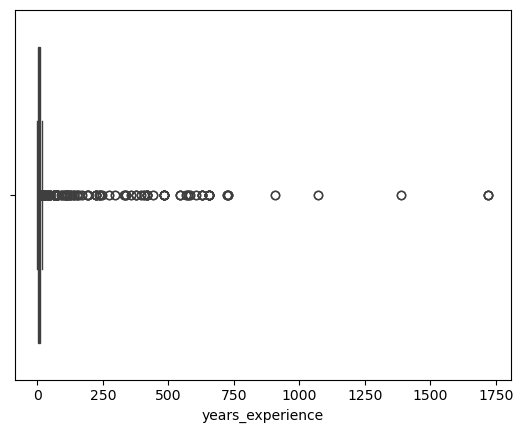

In [126]:
sns.boxplot(x=df['years_experience'])
plt.show()

## Descriptive Analysis

In [129]:
df.head()


,application_id,stage,outcome,gender,department,region,experience_level,years_experience,university,gpa,...,application_date,stage_date,days_in_stage,days_since_application,interviewer_rating,interview_notes,salary_offered,salary_accepted,quarter,month
0,App_00001,Application,Advanced,Male,Product,North America,Entry,1.049549,Ucla,3.428883,...,2025-01-30 04:04:49.887103,2025-01-30 04:04:49.887103,0,0.0,3.0,"Excellent Cultural Fit, Very Enthusiastic",90906.0,94229.0,2025Q1,2025-01
1,App_00002,Application,Advanced,Female,Operations,Latin America,Staff/Principal,11.256188,State University,3.353741,...,2025-06-15 04:04:49.887811,2025-06-15 04:04:49.887811,0,0.0,3.0,"Excellent Cultural Fit, Very Enthusiastic",90906.0,94229.0,2025Q2,2025-06
2,App_00003,Application,Advanced,Male,Product,Europe,Senior,8.559995,State University,3.434819,...,2025-03-18 04:04:49.887992,2025-03-18 04:04:49.887992,0,0.0,3.0,"Excellent Cultural Fit, Very Enthusiastic",90906.0,94229.0,2025Q1,2025-03
3,App_00004,Application,Advanced,Male,Operations,Asia Pacific,Entry,0.073774,Ucla,2.632492,...,2025-03-08 04:04:49.888144,2025-03-08 04:04:49.888144,0,0.0,3.0,"Excellent Cultural Fit, Very Enthusiastic",90906.0,94229.0,2025Q1,2025-03
4,App_00005,Application,Advanced,Male,Engineering,Asia Pacific,Entry,1.059301,Columbia,3.817544,...,2025-01-29 04:04:49.888305,2025-01-29 04:04:49.888305,0,0.0,3.0,"Excellent Cultural Fit, Very Enthusiastic",90906.0,94229.0,2025Q1,2025-01


In [131]:
df['stage'].unique()

array(['Application', 'Phone Screen', 'Technical Interview',
       'Panel Interview', 'Final Interview', 'Offer', 'Hire'],
      dtype=object)

In [181]:
#Application pipeline by stage
application_pipeline=df.groupby('stage',as_index=False)['application_id'].size()
application_pipeline=application_pipeline.sort_values('size',ascending=False)

/var/folders/3f/21w5vqzs3k35ybl9kpx55zk40000gn/T/ipykernel_90923/3749818858.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(application_pipeline,x='size',y='stage',palette='Spectral')


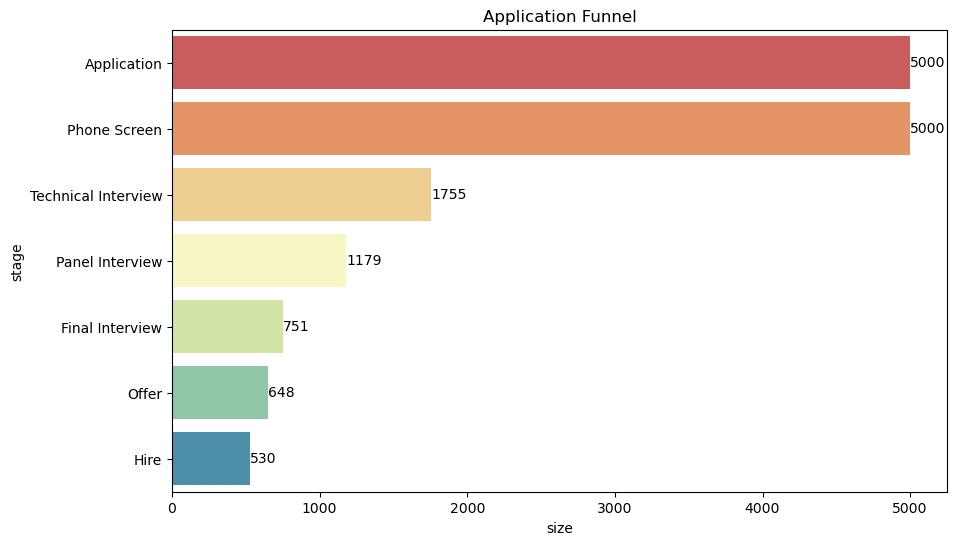

In [187]:
plt.figure(figsize=(10,6))
ax=sns.barplot(application_pipeline,x='size',y='stage',palette='Spectral')
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('Application Funnel')
plt.show()

In [191]:
stage_counts = df.groupby('stage').size()
stage_counts

stage
Application            5000
Final Interview         751
Hire                    530
Offer                   648
Panel Interview        1179
Phone Screen           5000
Technical Interview    1755
dtype: int64

In [246]:
Application_Phone_Screen =  stage_counts['Phone Screen']/stage_counts['Application']
print(f"Application --> Phone_Screen:{round(Application_Phone_Screen,2)}%")
Phone_Screen_Technical_Interview =  stage_counts['Technical Interview']/stage_counts['Phone Screen']
print(f"Phone_Screen -->Technical Interview  :{round(Phone_Screen_Technical_Interview,2)}%")

Technical_Interview_Panel_Interview =  stage_counts['Panel Interview']/stage_counts['Technical Interview']
print(f"Technical Interview --> Panel Interview :{round(Technical_Interview_Panel_Interview,2)}%")

Panel_Interview_Final_Interview =  stage_counts['Final Interview']/stage_counts['Panel Interview']
print(f"Panel Interview --> Final Interview :{round(Panel_Interview_Final_Interview,2)}%")

Final_Interview_Offer =  stage_counts['Offer']/stage_counts['Final Interview']
print(f"Final Interview --> Offer :{round(Final_Interview_Offer,2)}%")

Offer_Hire =  stage_counts['Hire']/stage_counts['Offer']
print(f"Offer --> Hire:{round(Offer_Hire,2)}%")



Application --> Phone_Screen:1.0%
Phone_Screen -->Technical Interview  :0.35%
Technical Interview --> Panel Interview :0.67%
Panel Interview --> Final Interview :0.64%
Final Interview --> Offer :0.86%
Offer --> Hire:0.82%


In [256]:
Funnel_Conversion_rate= {'Application_Phone_Screen':Application_Phone_Screen,'Phone_Screen_Technical_Interview':Phone_Screen_Technical_Interview
                        ,'Technical_Interview_Panel_Interview':Technical_Interview_Panel_Interview,
                        'Panel_Interview_Final_Interview':Panel_Interview_Final_Interview,'Final_Interview_Offer':Final_Interview_Offer,'Offer_Hire':Offer_Hire}
Funnel_Conversion_rate


{'Application_Phone_Screen': 1.0,
 'Phone_Screen_Technical_Interview': 0.351,
 'Technical_Interview_Panel_Interview': 0.6717948717948717,
 'Panel_Interview_Final_Interview': 0.636980491942324,
 'Final_Interview_Offer': 0.8628495339547271,
 'Offer_Hire': 0.8179012345679012}

In [266]:
Funnel_Conversion_Analysis=pd.Series(Funnel_Conversion_rate)
Funnel_Conversion_Analysis.sort_values(ascending=False)

Application_Phone_Screen               1.000000
Final_Interview_Offer                  0.862850
Offer_Hire                             0.817901
Technical_Interview_Panel_Interview    0.671795
Panel_Interview_Final_Interview        0.636980
Phone_Screen_Technical_Interview       0.351000
dtype: float64

/var/folders/3f/21w5vqzs3k35ybl9kpx55zk40000gn/T/ipykernel_90923/3137479898.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Funnel_Conversion_Analysis.values,y=Funnel_Conversion_Analysis.index,palette='Blues_d')


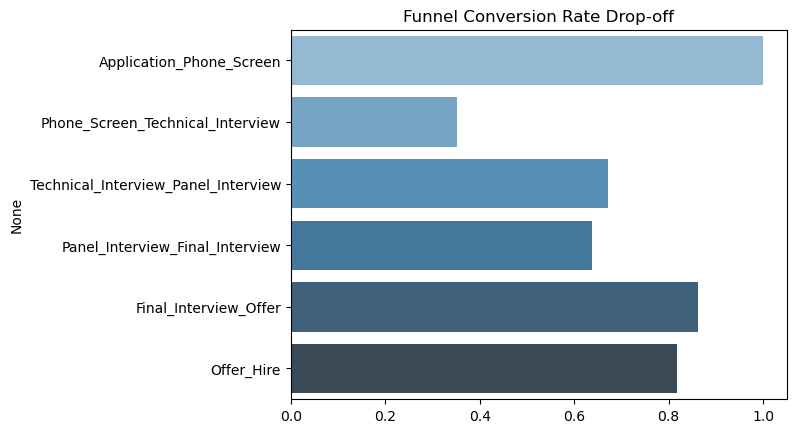

In [272]:
sns.barplot(x=Funnel_Conversion_Analysis.values,y=Funnel_Conversion_Analysis.index,palette='Blues_d')
plt.title('Funnel Conversion Rate Drop-off')
plt.show()

In [280]:
#Demographic by Conversion

conversion_by_gender=df.groupby(['gender','stage'],as_index=False).size().fillna(0)
conversion_by_gender

,gender,stage,size
0,Female,Application,1541
1,Female,Final Interview,230
2,Female,Hire,159
3,Female,Offer,201
4,Female,Panel Interview,374
5,Female,Phone Screen,1541
6,Female,Technical Interview,540
7,Male,Application,3196
8,Male,Final Interview,485
9,Male,Hire,346


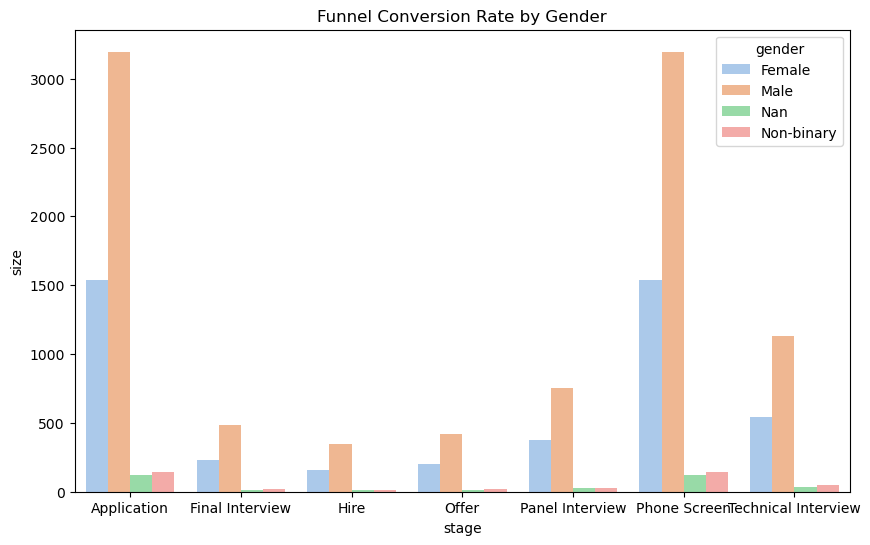

In [288]:
plt.figure(figsize=(10,6))
sns.barplot(conversion_by_gender,x='stage',y='size',hue='gender',palette='pastel')
plt.title('Funnel Conversion Rate by Gender')
plt.show()

In [290]:
df.columns

Index(['application_id', 'stage', 'outcome', 'gender', 'department', 'region',
       'experience_level', 'years_experience', 'university', 'gpa',
       'recruiter', 'source', 'skills', 'num_skills', 'resume_score',
       'previous_company_type', 'phone', 'email', 'application_date',
       'stage_date', 'days_in_stage', 'days_since_application',
       'interviewer_rating', 'interview_notes', 'salary_offered',
       'salary_accepted', 'quarter', 'month'],
      dtype='object')

In [292]:
#Female in Tech
female_count=df[df['gender']=='Female'].shape[0]
female_count

4586

In [304]:
#female department wise

female_in_tech=df[df['gender']=='Female'].groupby('department',as_index=False)['gender'].size()
female_in_tech.sort_values('size',ascending=False)

,department,size
2,Finance,607
4,Marketing,606
3,Hr,601
5,Operations,590
6,Product,586
0,Data Science,547
1,Engineering,533
7,Sales,516


/var/folders/3f/21w5vqzs3k35ybl9kpx55zk40000gn/T/ipykernel_90923/922665989.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(female_in_tech,x='department',y='size',palette='pastel')


<Figure size 1000x600 with 0 Axes>

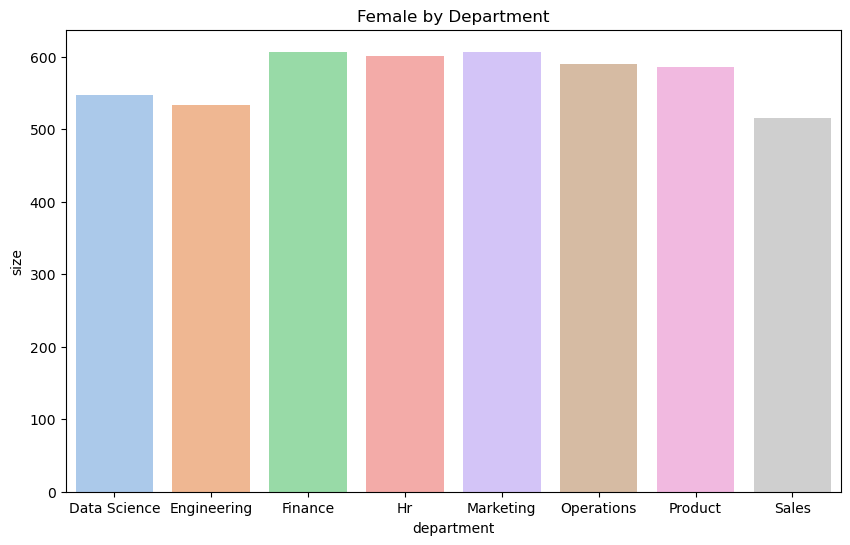

In [308]:
plt.figure(figsize=(10,6))
sns.barplot(female_in_tech,x='department',y='size',palette='pastel')
plt.title('Female by Department')
plt.show()

In [312]:
df.head()

,application_id,stage,outcome,gender,department,region,experience_level,years_experience,university,gpa,...,application_date,stage_date,days_in_stage,days_since_application,interviewer_rating,interview_notes,salary_offered,salary_accepted,quarter,month
0,App_00001,Application,Advanced,Male,Product,North America,Entry,1.049549,Ucla,3.428883,...,2025-01-30 04:04:49.887103,2025-01-30 04:04:49.887103,0,0.0,3.0,"Excellent Cultural Fit, Very Enthusiastic",90906.0,94229.0,2025Q1,2025-01
1,App_00002,Application,Advanced,Female,Operations,Latin America,Staff/Principal,11.256188,State University,3.353741,...,2025-06-15 04:04:49.887811,2025-06-15 04:04:49.887811,0,0.0,3.0,"Excellent Cultural Fit, Very Enthusiastic",90906.0,94229.0,2025Q2,2025-06
2,App_00003,Application,Advanced,Male,Product,Europe,Senior,8.559995,State University,3.434819,...,2025-03-18 04:04:49.887992,2025-03-18 04:04:49.887992,0,0.0,3.0,"Excellent Cultural Fit, Very Enthusiastic",90906.0,94229.0,2025Q1,2025-03
3,App_00004,Application,Advanced,Male,Operations,Asia Pacific,Entry,0.073774,Ucla,2.632492,...,2025-03-08 04:04:49.888144,2025-03-08 04:04:49.888144,0,0.0,3.0,"Excellent Cultural Fit, Very Enthusiastic",90906.0,94229.0,2025Q1,2025-03
4,App_00005,Application,Advanced,Male,Engineering,Asia Pacific,Entry,1.059301,Columbia,3.817544,...,2025-01-29 04:04:49.888305,2025-01-29 04:04:49.888305,0,0.0,3.0,"Excellent Cultural Fit, Very Enthusiastic",90906.0,94229.0,2025Q1,2025-01


In [316]:
df['outcome'].unique()

array(['Advanced', 'Rejected'], dtype=object)

In [318]:
df.columns

Index(['application_id', 'stage', 'outcome', 'gender', 'department', 'region',
       'experience_level', 'years_experience', 'university', 'gpa',
       'recruiter', 'source', 'skills', 'num_skills', 'resume_score',
       'previous_company_type', 'phone', 'email', 'application_date',
       'stage_date', 'days_in_stage', 'days_since_application',
       'interviewer_rating', 'interview_notes', 'salary_offered',
       'salary_accepted', 'quarter', 'month'],
      dtype='object')

In [330]:
df['time_to_hire']=(df['stage_date']-df['application_date']).dt.days
time_to_hire

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
14858    30.0
14859    49.0
14860    68.0
14861    61.0
14862    67.0
Length: 14863, dtype: float64

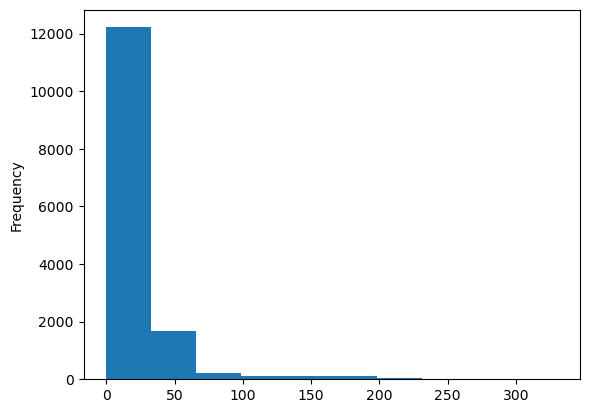

In [332]:
time_to_hire.plot(kind='hist')
plt.show()

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

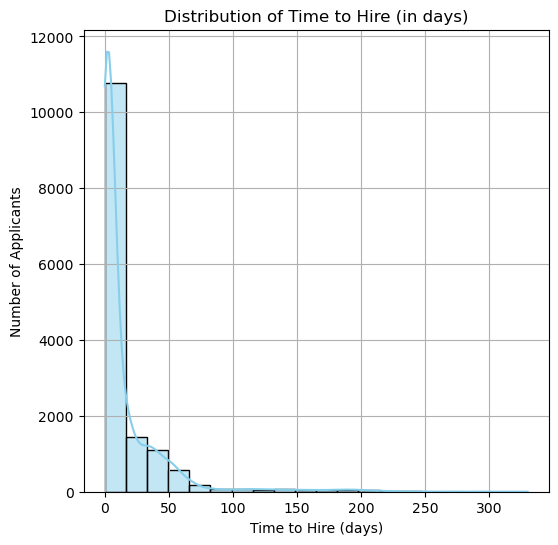

In [350]:
# Drop missing or negative values (if any)
valid_hires = df[df['time_to_hire'].notna() & (df['time_to_hire'] >= 0)]

# Plot histogram
plt.figure(figsize=(6, 6))
sns.histplot(df['time_to_hire'], bins=20, kde=True, color='skyblue')

plt.title('Distribution of Time to Hire (in days)')
plt.xlabel('Time to Hire (days)')
plt.ylabel('Number of Applicants')
plt.grid(True)
plt.show()

In [352]:
# Multi-dimensional analysis
pivot_analysis = df.pivot_table(
    values='application_id', 
    index=['gender', 'department'], 
    columns='stage', 
    aggfunc='nunique',
    fill_value=0
)

In [354]:
pivot_analysis

stage                    Application  Final Interview  Hire  Offer  \
gender     department                                                
Female     Data Science          195               20    11     17   
           Engineering           190               20    15     18   
           Finance               203               32    21     28   
           Hr                    200               31    24     27   
           Marketing             188               36    27     34   
           Operations            196               33    20     27   
           Product               193               31    19     25   
           Sales                 176               27    22     25   
Male       Data Science          401               67    46     52   
           Engineering           396               56    40     48   
           Finance               396               61    41     51   
           Hr                    425               60    43     52   
           Marketing             412               50    39     45   
           Operations            377               63    40     53   
           Product               377               57    38     48   
           Sales                 412               71    59     69   
Nan        Data Science           16                1     1      1   
           Engineering            15                3     2      2   
           Finance                15                2     1      1   
           Hr                     16                1     0      0   
           Marketing              17                2     2      2   
           Operations             15                3     1      1   
           Product                12                0     0      0   
           Sales                  14                4     2      3   
Non-binary Data Science           12                3     3      3   
           Engineering            18                3     3      3   
           Finance                15                1     1      1   
           Hr                     24                3     2      2   
           Marketing              14                3     3      3   
           Operations             17                3     1      3   
           Product                25                1     1      1   
           Sales                  18                3     2      3   

stage                    Panel Interview  Phone Screen  Technical Interview  
gender     department                                                        
Female     Data Science               44           195                   65  
           Engineering                34           190                   66  
           Finance                    49           203                   71  
           Hr                         48           200                   71  
           Marketing                  59           188                   74  
           Operations                 48           196                   70  
           Product                    54           193                   71  
           Sales                      38           176                   52  
Male       Data Science              103           401                  144  
           Engineering                85           396                  138  
           Finance                    96           396                  137  
           Hr                         96           425                  148  
           Marketing                  86           412                  141  
           Operations                 87           377                  129  
           Product                    90           377                  136  
           Sales                     107           412                  160  
Nan        Data Science                2            16                    5  
           Engineering                 4            15                    5  
           Finance                     2            15     